<a href="https://colab.research.google.com/github/abdullahzulfiqar2550-gif/ML-Internship-Project/blob/python_project_for_beginner/Colifornia_House_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle
from sklearn.metrics import root_mean_squared_error, r2_score
print("ALL libraries are uploaded successfully")

ALL libraries are uploaded successfully


In [ ]:
housing=fetch_california_housing(as_frame=True)
X=housing.data
y=housing.target
print("Data Uploaded Successfully")
print(f"The Features X is {X.shape}")
print(f"The target y is {y.shape}")
print("The Description of data")
print(housing.DESCR[:500]+ "---")

Data Uploaded Successfully
The Features X is (20640, 8)
The target y is (20640,)
The Description of data
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu---


In [ ]:
# Display basic information about the dataset
print("Features Names")
print(X.columns.tolist())
print("Show first five rows of Features")
print(X.head())
print("Display first five rows of target")
print(y.head())
print("Display Description")
print(X.describe())

Features Names
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Show first five rows of Features
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
Display first five rows of target
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Display Description
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean 

# Data Exploration and Visualization

In [ ]:
# Check missing value
print("Missing value in features")
print(X.isnull().sum())
print("\nMissing value in target", y.isnull().sum())

# Basic Statistics
print("\n Target Variable Statistics")
print(f"Mean house Value : ${y.mean():.2f}(in hundred of thousands)")
print(f"Median house Value : ${y.median():.2f}(in hundred of thousands)")
print(f"Minimum house Value : ${y.min():.2f}(in hundred of thousands)")
print(f"Maximum house Value : ${y.max():.2f}(in hundred of thousands)")

Missing value in features
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Missing value in target 0

 Target Variable Statistics
Mean house Value : $2.07(in hundred of thousands)
Median house Value : $1.80(in hundred of thousands)
Minimum house Value : $0.15(in hundred of thousands)
Maximum house Value : $5.00(in hundred of thousands)


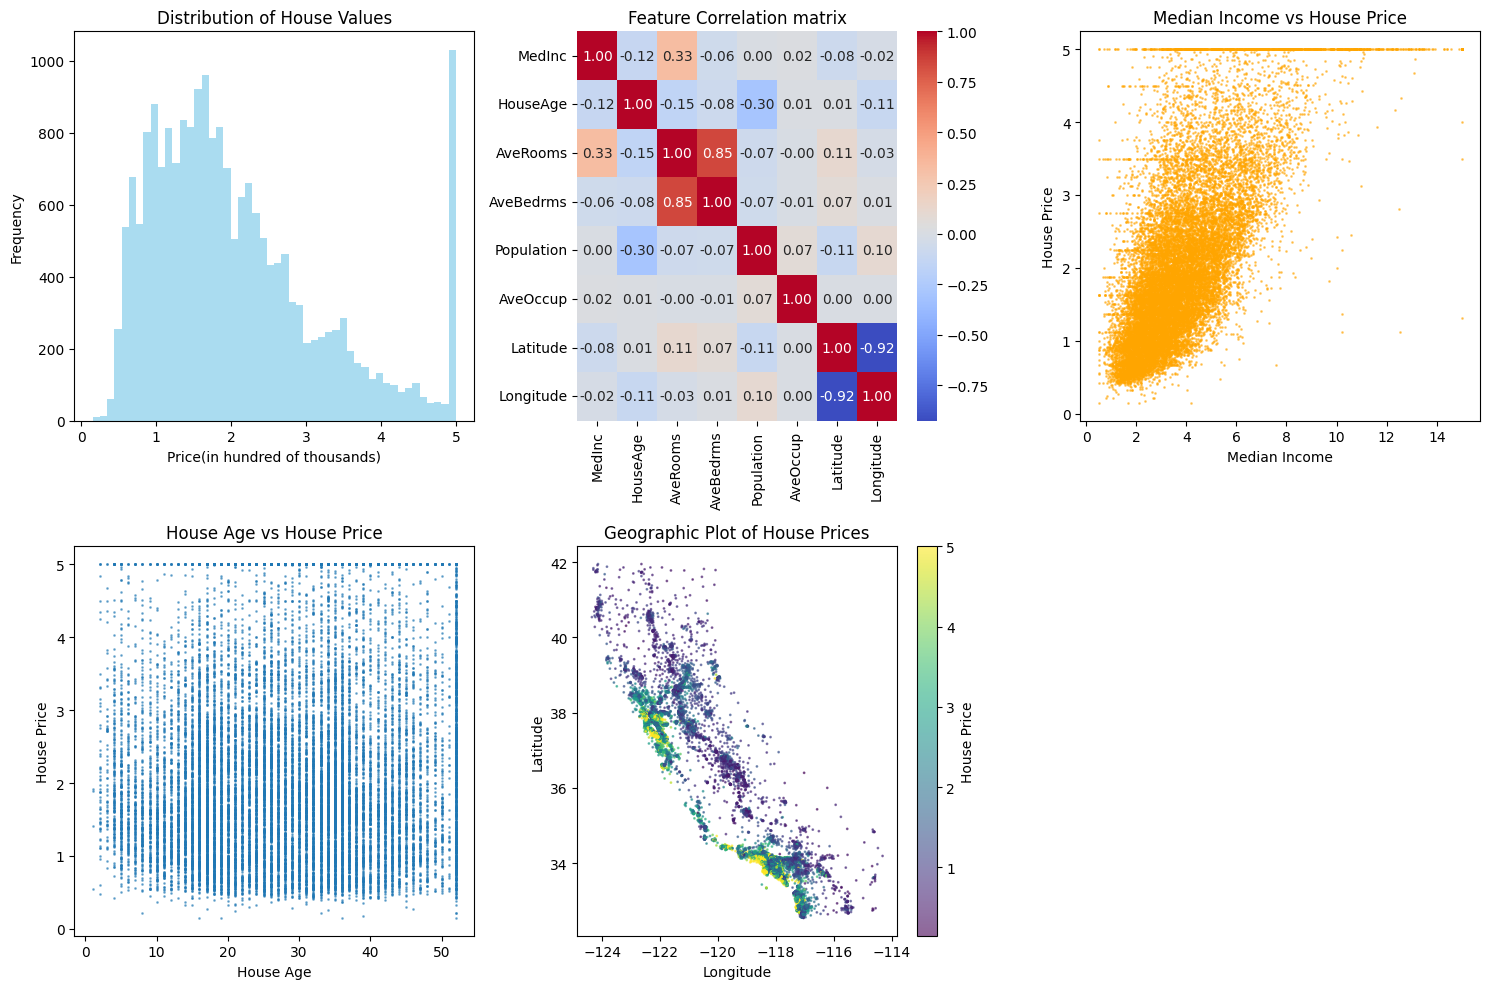

In [ ]:
# create visualzation
plt.figure(figsize=(15,10))

# Distribution of target variable
plt.subplot(2,3,1)
plt.hist(y, bins=50, alpha=0.7, color='skyblue')
plt.title("Distribution of House Values")
plt.xlabel("Price(in hundred of thousands)")
plt.ylabel("Frequency")

# Correlation Heatmap
plt.subplot(2,3,2)
correlation_matrix=X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation matrix")

# Scatter plot MedInc vs Price
plt.subplot(2,3,3)
plt.scatter(X['MedInc'],y, alpha=0.5, color='orange',s =1)
plt.title("Median Income vs House Price")
plt.xlabel("Median Income")
plt.ylabel("House Price")

# Scatter Plot: HouseAge vs Price
plt.subplot(2,3,4)
plt.scatter(X['HouseAge'], y, alpha=0.5, s=1)
plt.title("House Age vs House Price")
plt.xlabel("House Age")
plt.ylabel("House Price")

# Geographic plot
plt.subplot(2,3,5)
plt.scatter(X['Longitude'], X['Latitude'], c=y , cmap='viridis',alpha=0.6, s=1)
plt.colorbar(label='House Price')
plt.title("Geographic Plot of House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [ ]:
# split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, shuffle=True)

print("Data split Completely")
print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape : {y_test.shape}")

print(f"\n Training set : {len(X_train)} samples ({len(X_train)})")
print(f"Testing set : {len(X_test)} samples ({len(X_test)})")

Data split Completely
X_train Shape : (16512, 8)
X_test Shape : (4128, 8)
y_train Shape : (16512,)
y_test Shape : (4128,)

 Training set : 16512 samples (16512)
Testing set : 4128 samples (4128)


# Scale the feature using StandardScaler

In [ ]:
# this is important for linear regression to ensure all feature are equally distribute
scaler=StandardScaler()
# fit the scaler on training data and transform both training and testing data
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("Features scaling completely")
print("\n Original X_train statistics")
print(f"Mean : {X_train.mean().mean():.3f}")
print(f"Standard Deviation : {X_train.std().mean():.3f}")

print("\n Scaled X_train statistics")
print(f"Mean : {X_train_scaled.mean():.3f}")
print(f"Standard Deviation : {X_train_scaled.std():.3f}")

print("\n First 5 rows of scaled X_train")
print(X_train_scaled[:5])

Features scaling completely

 Original X_train statistics
Mean : 173.079
Standard Deviation : 146.263

 Scaled X_train statistics
Mean : 0.000
Standard Deviation : 1.000

 First 5 rows of scaled X_train
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


# **6. Model Training**

In [ ]:
# Initialize the linear Regression model
model=LinearRegression()
print("Training the Linear Regression Model")

# train the model
model.fit(X_train_scaled, y_train)

print("Model training complete!")
print(f"\n Model coefficients : {model.coef_}")
print(f"\n Model intercept : {model.intercept_}")

Training the Linear Regression Model
Model training complete!

 Model coefficients : [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]

 Model intercept : 2.0719469373788777


# **Model Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

# Make prediction on both training and testing sets
y_train_pred=model.predict(X_train_scaled)
y_test_pred=model.predict(X_test_scaled)

# Calculate evaluation metrics
train_rmse=root_mean_squared_error(y_train, y_train_pred)
test_rmse=root_mean_squared_error(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2=r2_score(y_train, y_train_pred)
test_r2=r2_score(y_test, y_test_pred)

print("Model Evaluation Result")
print("=" * 40)
print(f"Training set: ")
print(f" Root Mean Squared Error: {train_rmse:.2f}")
print(f" Mean Squared Error: {train_mse:.2f}")
print(f" R^2 Score: {train_r2:.2f}")

print("\nTesting set: ")
print(f" Root Mean Squared Error: {test_rmse:.2f}")
print(f" Mean Squared Error: {test_mse:.2f}")
print(f" R^2 Score: {test_r2:.2f}")

Model Evaluation Result
Training set: 
 Root Mean Squared Error: 0.72
 Mean Squared Error: 0.52
 R^2 Score: 0.61

Testing set: 
 Root Mean Squared Error: 0.75
 Mean Squared Error: 0.56
 R^2 Score: 0.58


# Again Visualization but i am to skip the concept so please try on its own

# Save the trained model using pickle

In [ ]:
# Save the trained model using pickle
model_filename= 'linear_regression_model.pkl'
with open (model_filename, "wb") as file:
  pickle.dump(model,file)
print(f" Trained model saved to {model_filename}")

# save the scaler as well (very important for deployment)
scaler_filename='scaler.pkl'
with open(scaler_filename, 'wb') as file:
  pickle.dump(scaler,file)
print(f"Scaler saved to {scaler_filename}")

# verify that we can load the model back
print("\n Verifying saved files....")
with open(model_filename, 'rb') as file:
  loaded_model=pickle.load(file)
with open(scaler_filename, 'rb') as file:
  loaded_scaler=pickle.load(file)
print("Model and scaler loaded succcessfully for verifcation")

# test the loaded model with a sample prediction
sample_prediction=loaded_model.predict(X_test_scaled[:1])
print(f"\n Sample prediction using loaded model: {sample_prediction[0]}")
print(f"Actual value for sample: $ {y_test.iloc[0]*100:.0f}")
print(f"prediction error: $ {abs(sample_prediction[0] - y_test.iloc[0])*100:.0f}")

 Trained model saved to linear_regression_model.pkl
Scaler saved to scaler.pkl

 Verifying saved files....
Model and scaler loaded succcessfully for verifcation

 Sample prediction using loaded model: 0.7191228416019144
Actual value for sample: $ 48
prediction error: $ 24


In [ ]:
from fastapi import FastAPI, HTTPException
from fastapi.responses import HTMLResponse
from pydantic import BaseModel
import pickle
import numpy as np
import pandas as pd
from typing import List
import uvicorn
import nest_asyncio
import threading # Import threading

# Initialize FastAPI app
app=FastAPI(
    title='House Price Prediction API',
    description='API for predicting house prices using a linear regression model',
    version='1.0.0'
)

# Load the trained model and scaler
try:
  with open('linear_regression_model.pkl', 'rb') as file:
    model=pickle.load(file)
  with open('scaler.pkl', 'rb') as file:
    scaler=pickle.load(file)
  print("Model and scaler loaded successfully")
except FileNotFoundError as e:
  print(f"Error loading model or scaler: {e}")
  print("Please make sure the model and scaler files are present in the current directory")

# Define the input data model
class HouseInput(BaseModel):
  MedInc: float
  HouseAge: float
  AveRooms: float
  AveBedrms: float
  Population: float
  AveOccup: float
  Latitude: float
  Longitude: float

# Define the output data model
class PredictionOutput(BaseModel):
  """Response model for prediction"""
  predicted_price: float
  input_features: dict
  prediction_error: float # This field is defined but not calculated in the current predict logic

@app.get("/", response_class=HTMLResponse)
async def root():
    return "<h1>Welcome to the House Price Prediction API!</h1><p>Use the /predict endpoint to get house price predictions.</p>"

@app.post('/predict', response_model=PredictionOutput)
async def predict(features: HouseInput):
  try:
    # convert input into numpy array
    input_data=np.array([[
        features.MedInc,
        features.HouseAge,
        features.AveRooms,
        features.AveBedrms,
        features.Population,
        features.AveOccup,
        features.Latitude,
        features.Longitude
    ]])

    # scale the input data using the saved scaler
    input_scaled=scaler.transform(input_data)
    # Make prediction
    prediction=model.predict(input_scaled)[0]

    # convert prediction to a more readable format (multiply by 100,000 for actual price )
    predicted_price=float(prediction * 100000) # convert to actual price sacle

    # For demonstration, we can set prediction_error to 0 as we don't have actual labels here
    # In a real scenario, this might be calculated if a ground truth was provided or estimated
    prediction_error = 0.0 # Placeholder for now

    return PredictionOutput(
        predicted_price=predicted_price,
        input_features=features.dict(),
        prediction_error=prediction_error
    )
  except Exception as e:
      raise HTTPException(status_code=500, detail=f"predict error: {str(e)}")

# Example usage and testing
if __name__ == "__main__":
    nest_asyncio.apply() # Apply nest_asyncio to allow nested event loops

    # Run the server in a separate thread to avoid RuntimeError in Colab
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
    server = uvicorn.Server(config)

    # Create a thread to run the server
    server_thread = threading.Thread(target=server.run)
    server_thread.start()

    print("FastAPI server started at http://0.0.0.0:8000")
    print("You can access the API at /predict endpoint (e.g., http://localhost:8000/predict)")
    print("To stop the server, interrupt the kernel or close the Colab tab.")

Model and scaler loaded successfully
FastAPI server started at http://0.0.0.0:8000
You can access the API at /predict endpoint (e.g., http://localhost:8000/predict)
To stop the server, interrupt the kernel or close the Colab tab.
